In [1]:
%load_ext autoreload 
%autoreload 2

In [3]:
from tqdm import tqdm
import torch
import torchaudio
import matplotlib.pyplot as plt
from IPython.display import Audio

from ptrd import utils
import ptrd.torch_audio_dsp.synth as tas
import ptrd.jupylet_audio.synth as ja

/Users/trippgordon/off_icloud/Code/parted-record/ptrd/jupylet_audio/sound.py:1085: UserWarning: Explicitly requested dtype float64 requested in zeros is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  _JNP_ZERO = jnp.zeros((1,), dtype='float64')


#### target 

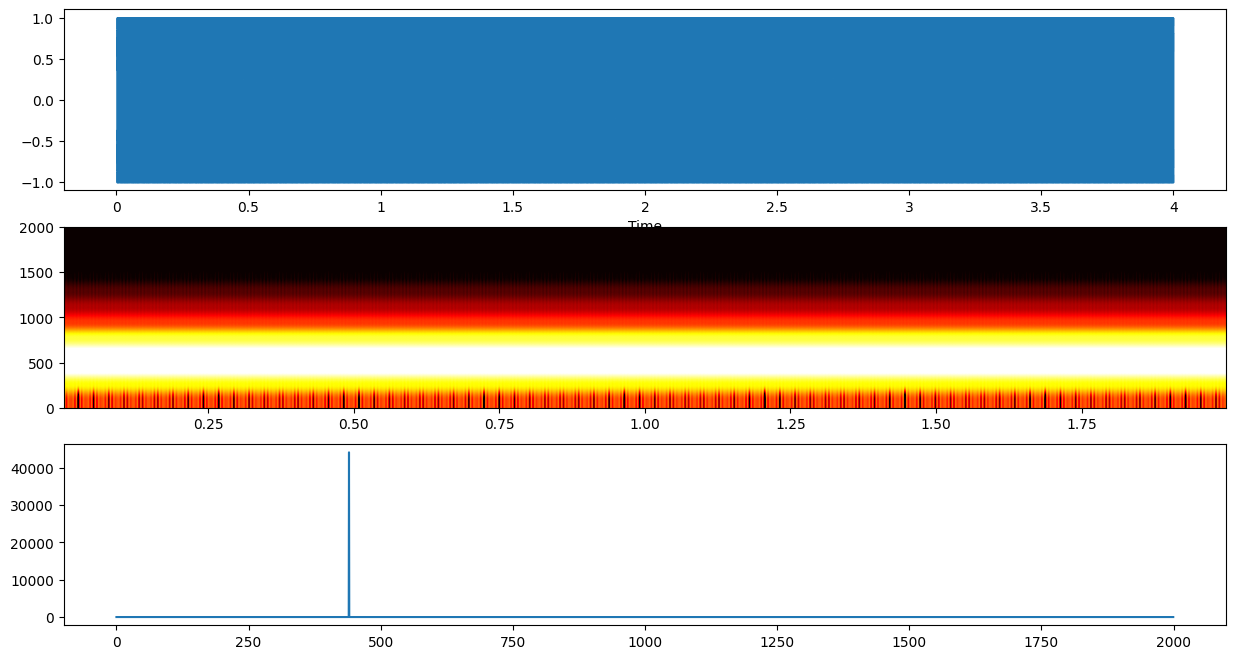

In [16]:
a0 = tas.sine()
utils.visualize_sample(a0, freq_range=(0, 2000) )

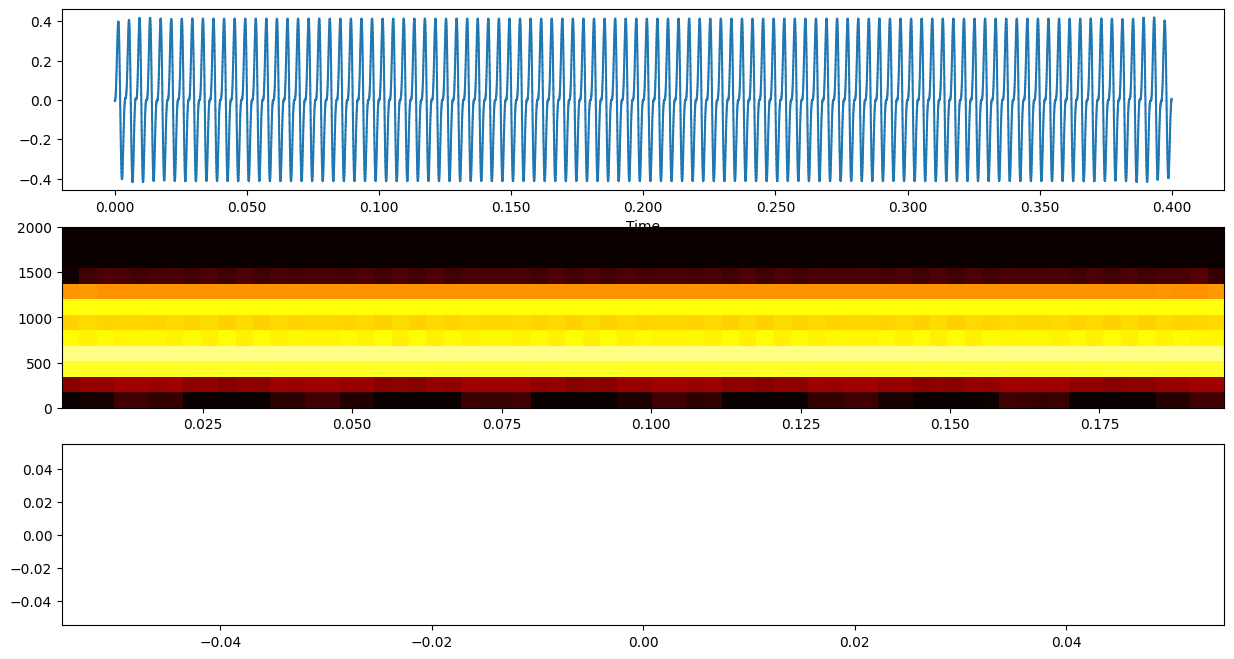

In [31]:
# constant synth params
f0 = 500
duration = 0.2
sr = utils.FPS
target_cutoff = 1000

# generate target sample 
target_a0 = tas.filt(
    tas.saw(f0=f0, duration=duration, sr=sr),
    cutoff=target_cutoff,
    window_size=2049
)

utils.visualize_sample(target_a0, freq_range=(0, 2000), )

#### model

In [32]:

class SynthModel(torch.nn.Module): 
    def __init__(self):
        super().__init__()
        self.normalized_cutoff = torch.nn.parameter.Parameter(torch.tensor(0.5))
        
    def forward(self, f0=40, duration=0.2, sr=utils.FPS): 
        ''' 
            - f0 (float): fundamental note frequency
            - duration (float): seconds 
            - sr: sample rate (per second)
        '''
        a0 = tas.saw(f0=f0, duration=duration, sr=sr)
        # run through sigmoid 
        cutoff = self.normalized_cutoff * 20000
        a0 = tas.filt(a0, cutoff=cutoff, window_size=2049)
        return a0
    
model = SynthModel()

#### train

In [24]:
lr = 0.001

# register cutoff as a parameter managed & updated by optimizer
params = [model.normalized_cutoff]

optim = torch.optim.AdamW(
    params, 
    lr=lr, 
    eps=1e-4
)


In [25]:
# loss
def mae(pred, target): 
    # mean absolute error for monophonic audio signals 
    pred = pred.squeeze()
    target = target.squeeze()
    mae = (pred - target).abs().mean()
    return mae

def fft_mae(pred, target): 
    
    # squeeze & normalize
    pred = pred.squeeze() / pred.max()
    target = target.squeeze() / target.max()
    
    pred_fft = torch.fft.rfft(pred)
    target_fft = torch.fft.rfft(target)
    
    mae = (pred_fft - target_fft).abs().mean()
    return mae
    

def fmt(x):
    return f'{x : .3f}'

In [26]:
with tqdm(range(1000)) as pbar:
    
    for i in pbar:
        optim.zero_grad()
        pred_a0 = model(f0=800, duration=duration, sr=sr)

        # loss = mae(pred_a0, target_a0)
        loss = fft_mae(pred_a0, target_a0)

        loss.backward()
        optim.step()
        pbar.set_description((
            f'l: {loss.item() :.2f} \t'
            f'cutoff: {model.normalized_cutoff.item() * 20000 :.0f} \t'

        ))

  0%|                                                                                                     | 0/1000 [00:00<?, ?it/s]/Users/trippgordon/off_icloud/Code/parted-record/ptrd/torch_audio_dsp/_dsp.py:60: UserWarning: Some frequencies are above nyquist frequency. Setting the corresponding amplitude to zero. This might cause numerically unstable gradient.
  warnings.warn(
l: 0.00 	cutoff: 1196 	: 100%|█████████████████████████████████████████████████████████████████| 1000/1000 [03:24<00:00,  4.89it/s]
